# Policy Comparison

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from battery_sim.battery.battery import Battery
from battery_sim.agents.policies.rule_based import ThresholdPolicy
from battery_sim.agents.policies.probabilistic import ProbabilisticThresholdPolicy
from battery_sim.agents.policies.continuous_probabilistic import ContinuousProbabilisticPolicy
from battery_sim.agents.policies.median_threshold import MedianThresholdPolicy
from battery_sim.agents.policies.reinforce import REINFORCEPolicy
from battery_sim.agents.policies.dqn import DQNPolicy
from battery_sim.agents.policies.mppi import MPPIPolicy
from battery_sim.agents.policies.forecast_lp import ForecastLPPolicy
from battery_sim.agents.policies.oracle import OraclePolicy
from battery_sim.agents.policies._utils import make_mlp, PriceRelativeFeatures
from battery_sim.models.median_reversion import MedianReversionModel
from battery_sim.optimization.policy_optimizer import evaluate_full
from battery_sim.utils.plotting import plot_eval, plot_daily_revenue, plot_hourly_profile, compare_policies

In [2]:
# Load data
train_df = pd.read_csv('../data/NEM_NSW1_2025-01-01_2025-12-31_1h.csv')
test_df = pd.read_csv('../data/NEM_NSW1_2026-01-01_2026-03-01_1h.csv')

print(f'Train: {len(train_df)} rows ({train_df.iloc[0, 0]} to {train_df.iloc[-1, 0]})')
print(f'Test:  {len(test_df)} rows ({test_df.iloc[0, 0]} to {test_df.iloc[-1, 0]})')

Train: 8736 rows (2025-01-01 10:00:00 to 2025-12-31 09:00:00)
Test:  1416 rows (2026-01-01 10:00:00 to 2026-03-01 09:00:00)


In [3]:
# Battery config
# capacity is 200.0 mwh, charge rate is 100mw per hour
# very roughly based on New England 1 in NSW: https://gateway.icn.org.au/projects/14788/pg-14788
battery = Battery(
    capacity_mwh=200.0,
    max_charge_rate_mw=100,
    max_discharge_rate_mw=100,
    efficiency=0.9,
)

In [4]:
Q = 20
vals = np.quantile(train_df.price, q = [i/Q for i in range(1, Q)])
PARAM_GRID = {
    'buy_threshold':vals,
    'sell_threshold':vals,
}

# Pre-compute price series for RL feature extractors
all_prices = pd.concat([train_df, test_df], ignore_index=True)

## 1. Deterministic Threshold Policy

In [5]:
det_policy = ThresholdPolicy(
    buy_threshold=50.0,
    sell_threshold=200.0,
)

# Learn optimal thresholds on training data
det_policy.learn(
    train_data=train_df, 
    battery=battery, 
    num_iters=25, 
    window_len=24,
    param_grid=PARAM_GRID
)
print(f'Learned buy_threshold: {det_policy.buy_threshold}')
print(f'Learned sell_threshold: {det_policy.sell_threshold}')

Learned buy_threshold: 54.4225
Learned sell_threshold: 147.77833


## 2. Probabilistic Threshold Policy

In [6]:
price_model = MedianReversionModel(window_days=30, interval_minutes=60)

prob_policy = ProbabilisticThresholdPolicy(
    model=price_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
)

# Learn: fits model + grid searches thresholds
prob_policy.learn(
    train_data=train_df, 
    battery=battery, 
    num_iters=10, 
    window_len=24,
    param_grid=PARAM_GRID
)
print(f'Learned buy_threshold: {prob_policy.buy_threshold}')
print(f'Learned sell_threshold: {prob_policy.sell_threshold}')

Learned buy_threshold: 132.1525
Learned sell_threshold: 168.311665


## 3. Continuous Probabilistic Policy

In [7]:
cont_model = MedianReversionModel(window_days=30, interval_minutes=60)

cont_policy = ContinuousProbabilisticPolicy(
    model=cont_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
)

cont_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24,
    param_grid=PARAM_GRID,
)
print(f'Learned buy_threshold: {cont_policy.buy_threshold}')
print(f'Learned sell_threshold: {cont_policy.sell_threshold}')

Learned buy_threshold: 61.613958000000004
Learned sell_threshold: 168.311665


## 4. Median Threshold Policy

In [8]:
med_model = MedianReversionModel(window_days=30, interval_minutes=60)

med_policy = MedianThresholdPolicy(model=med_model, spread=50.0)
med_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24,
)
print(f"Best spread: {med_policy.spread}")

Best spread: 75


## 5. REINFORCE Policy (Policy Gradient)

  iter 5/100  mean_return=-42156.77
  iter 10/100  mean_return=-22562.25
  iter 15/100  mean_return=-13851.58
  iter 20/100  mean_return=-52859.44
  iter 25/100  mean_return=-10341.79
  iter 30/100  mean_return=-17316.73
  iter 35/100  mean_return=-22783.61
  iter 40/100  mean_return=-29169.74
  iter 45/100  mean_return=-16595.97
  iter 50/100  mean_return=-22728.71
  iter 55/100  mean_return=-33192.24
  iter 60/100  mean_return=-22015.48
  iter 65/100  mean_return=-4192.36
  iter 70/100  mean_return=-18615.38
  iter 75/100  mean_return=-22406.97
  iter 80/100  mean_return=-20442.07
  iter 85/100  mean_return=-46717.66
  iter 90/100  mean_return=-23115.05
  iter 95/100  mean_return=-87075.92
  iter 100/100  mean_return=-23765.15


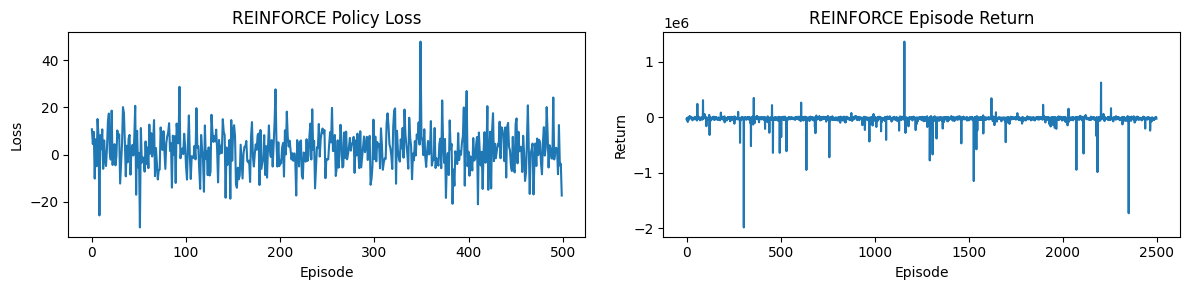

In [9]:
# REINFORCE: policy gradient with Beta action distribution (actions in [-1, 1])
# Uses extended features: [log_price, soc, rolling_median - price]
reinforce_features = PriceRelativeFeatures(all_prices, window_days=30)
reinforce_net = make_mlp(in_features=3, out_features=2, hidden=16)
reinforce_policy = REINFORCEPolicy(
    net=reinforce_net,
    feature_fn=reinforce_features,
    lr=5e-6,
    gamma=0.99,
    entropy_coef=0.01,
)

reinforce_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=100,
    window_len=24,
    n_windows=25,
)

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(reinforce_policy.loss_history)
ax1.set(xlabel='Episode', ylabel='Loss', title='REINFORCE Policy Loss')
ax2.plot(reinforce_policy.return_history)
ax2.set(xlabel='Episode', ylabel='Return', title='REINFORCE Episode Return')
plt.tight_layout()
plt.show()

## 6. DQN Policy (Deep Q-Learning)

  iter 5/100  loss=45.3458  epsilon=0.7626
  iter 10/100  loss=36.2537  epsilon=0.5846
  iter 15/100  loss=27.1311  epsilon=0.4510
  iter 20/100  loss=23.8643  epsilon=0.3508
  iter 25/100  loss=17.8731  epsilon=0.2756
  iter 30/100  loss=15.9608  epsilon=0.2193
  iter 35/100  loss=15.5596  epsilon=0.1770
  iter 40/100  loss=13.4296  epsilon=0.1452
  iter 45/100  loss=11.6267  epsilon=0.1214
  iter 50/100  loss=13.5977  epsilon=0.1036
  iter 55/100  loss=13.4630  epsilon=0.0902
  iter 60/100  loss=11.8916  epsilon=0.0802
  iter 65/100  loss=10.8893  epsilon=0.0726
  iter 70/100  loss=12.5075  epsilon=0.0670
  iter 75/100  loss=12.9378  epsilon=0.0627
  iter 80/100  loss=9.2686  epsilon=0.0595
  iter 85/100  loss=11.3313  epsilon=0.0572
  iter 90/100  loss=11.5117  epsilon=0.0554
  iter 95/100  loss=13.5956  epsilon=0.0540
  iter 100/100  loss=11.1293  epsilon=0.0530


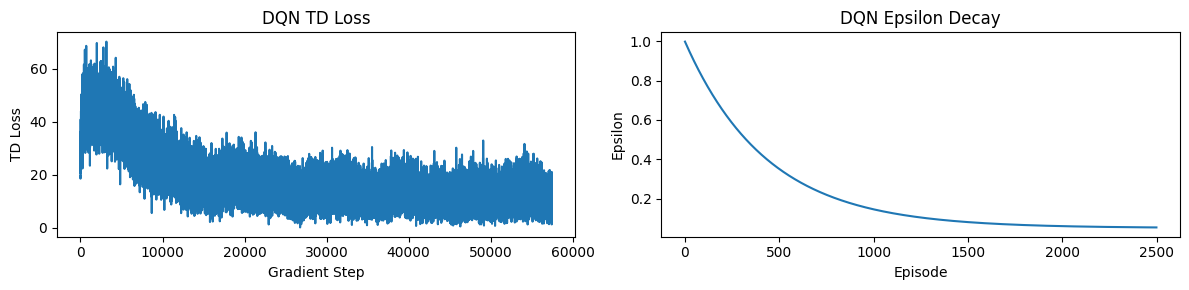

In [10]:
# DQN: discrete action Q-learning with replay buffer (actions in [-1, 1])
# Uses extended features: [log_price, soc, rolling_median - price]
dqn_features = PriceRelativeFeatures(all_prices, window_days=30)

dqn_net = make_mlp(in_features=3, out_features=21, hidden=32)
dqn_policy = DQNPolicy(
    net=dqn_net,
    feature_fn=dqn_features,
    n_actions=21,
    lr=3e-6,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=10000,
    batch_size=32,
    buffer_size=2000,
)

dqn_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=100,
    window_len=24,
    n_windows=25,
)

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(dqn_policy.loss_history)
ax1.set(xlabel='Gradient Step', ylabel='TD Loss', title='DQN TD Loss')
ax2.plot(dqn_policy.epsilon_history)
ax2.set(xlabel='Episode', ylabel='Epsilon', title='DQN Epsilon Decay')
plt.tight_layout()
plt.show()

## 7. MPPI (Model Predictive Path Integral) Policy

In [11]:
mppi_model = MedianReversionModel(window_days=30, interval_minutes=60)
mppi_policy = MPPIPolicy(
    model=mppi_model,
    battery=battery,
    horizon=12,
    n_samples=100,
    n_trajectories=100,
)

mppi_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=25,
    window_len=24,
)
print(f'Tuned noise_sigma: {mppi_policy.noise_sigma}')
print(f'Tuned temperature: {mppi_policy.temperature}')

Tuned noise_sigma: 0.2
Tuned temperature: 0.5


## 8. Forecast LP Policy (MPC with Model Forecasts)

In [12]:
forecast_lp_model = MedianReversionModel(window_days=30, interval_minutes=60)
forecast_lp_policy = ForecastLPPolicy(
    model=forecast_lp_model,
    battery=battery,
    horizon=12,
    interval_minutes=60,
)

forecast_lp_policy.learn(
    train_data=train_df,
    battery=battery,
)
print("Forecast LP policy trained")

Forecast LP policy trained


## 9. Oracle (Perfect Foresight)

In [13]:
oracle = OraclePolicy(price_data=test_df, battery=battery)
print(f'Oracle solved LP with {len(test_df) - 1} tradeable steps')

Oracle solved LP with 1415 tradeable steps


## 10. Evaluate on Test Set

In [14]:
# Re-fit models on train data before test evaluation
mppi_model.fit(train_df)
cont_model.fit(train_df)
forecast_lp_model.fit(train_df)
price_model.fit(train_df)
med_model.fit(train_df)

det_eval = evaluate_full('Deterministic Threshold', det_policy, test_df, battery)
prob_eval = evaluate_full('Probabilistic Threshold', prob_policy, test_df, battery)
cont_eval = evaluate_full('Continuous Probabilistic', cont_policy, test_df, battery)
med_eval = evaluate_full('Median Threshold', med_policy, test_df, battery)
reinforce_eval = evaluate_full('REINFORCE', reinforce_policy, test_df, battery)
dqn_eval = evaluate_full('DQN', dqn_policy, test_df, battery)
mppi_eval = evaluate_full('MPPI', mppi_policy, test_df, battery)
forecast_lp_eval = evaluate_full('Forecast LP', forecast_lp_policy, test_df, battery)
oracle_eval = evaluate_full('Oracle', oracle, test_df, battery)

all_evals = [det_eval, prob_eval, cont_eval, med_eval, reinforce_eval, dqn_eval, mppi_eval, forecast_lp_eval, oracle_eval]
for e in all_evals:
    print(e.summary())
    print()

Deterministic Threshold:
  Cumulative revenue: $624,015.26
  Mean daily revenue: $10,400.25 (+/- $31,165.89)
  Total steps: 1415

Probabilistic Threshold:
  Cumulative revenue: $466,835.11
  Mean daily revenue: $7,780.59 (+/- $28,176.85)
  Total steps: 1415

Continuous Probabilistic:
  Cumulative revenue: $781,990.50
  Mean daily revenue: $13,033.18 (+/- $58,424.62)
  Total steps: 1415

Median Threshold:
  Cumulative revenue: $874,758.07
  Mean daily revenue: $14,579.30 (+/- $40,592.06)
  Total steps: 1415

REINFORCE:
  Cumulative revenue: $-541,969.14
  Mean daily revenue: $-9,032.82 (+/- $31,498.38)
  Total steps: 1415

DQN:
  Cumulative revenue: $111,169.50
  Mean daily revenue: $1,852.83 (+/- $4,144.99)
  Total steps: 1415

MPPI:
  Cumulative revenue: $144,102.52
  Mean daily revenue: $2,401.71 (+/- $49,965.49)
  Total steps: 1415

Forecast LP:
  Cumulative revenue: $964,507.89
  Mean daily revenue: $16,075.13 (+/- $56,958.87)
  Total steps: 1415

Oracle:
  Cumulative revenue: $2,4

## 11. Hourly Profiles

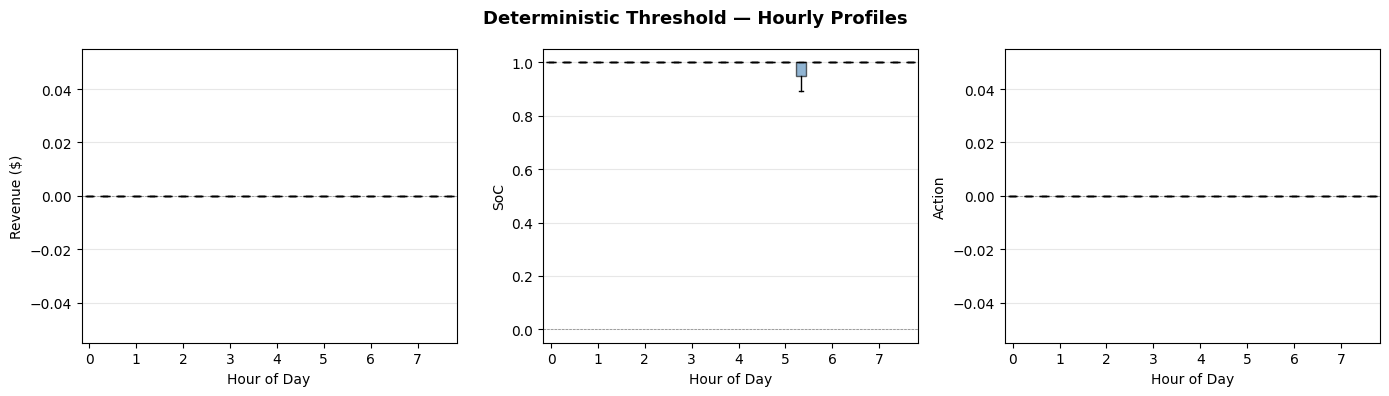

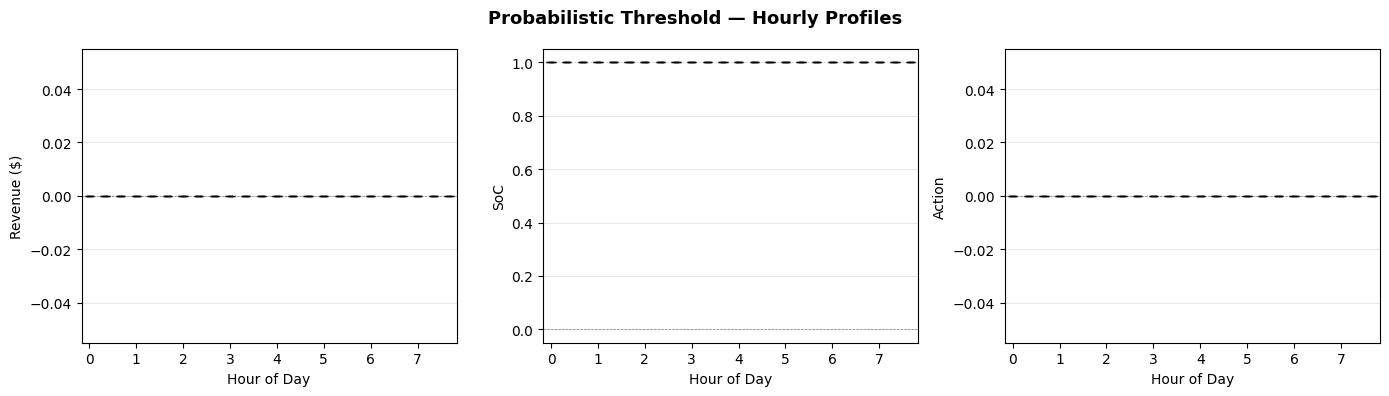

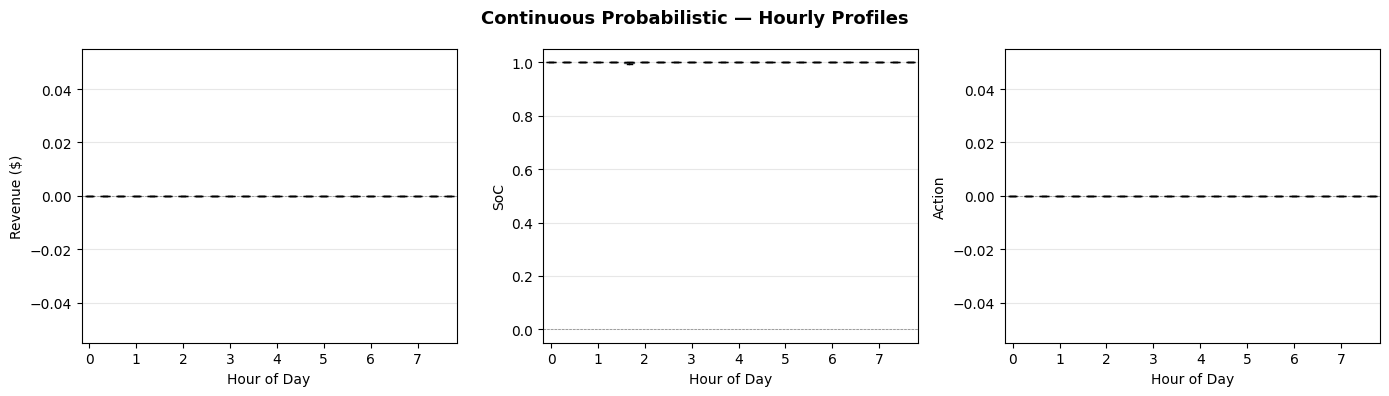

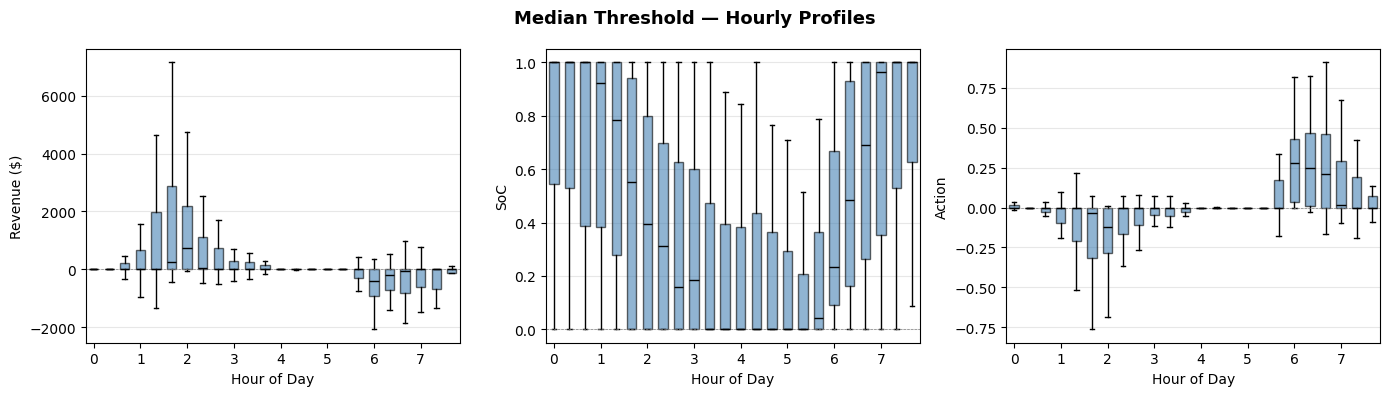

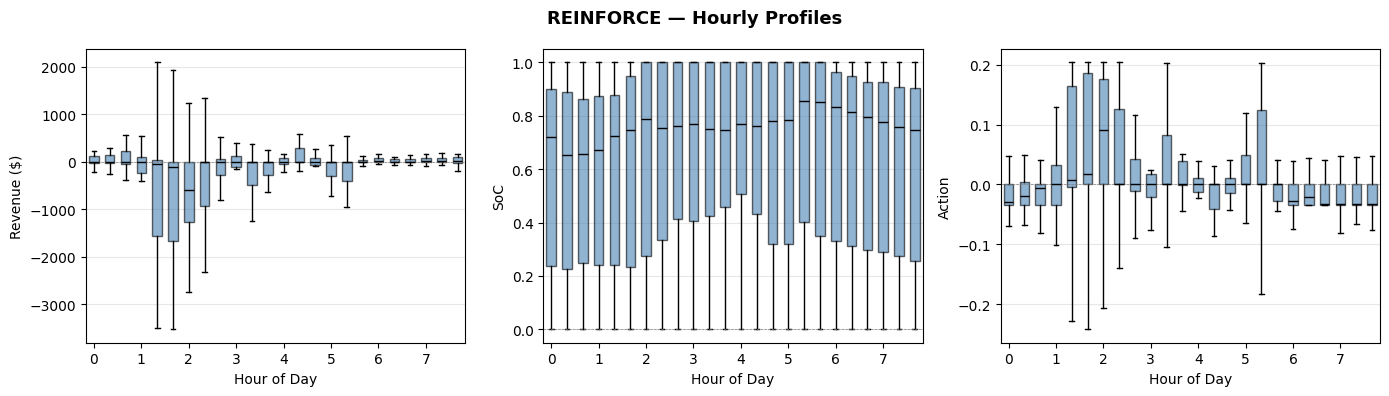

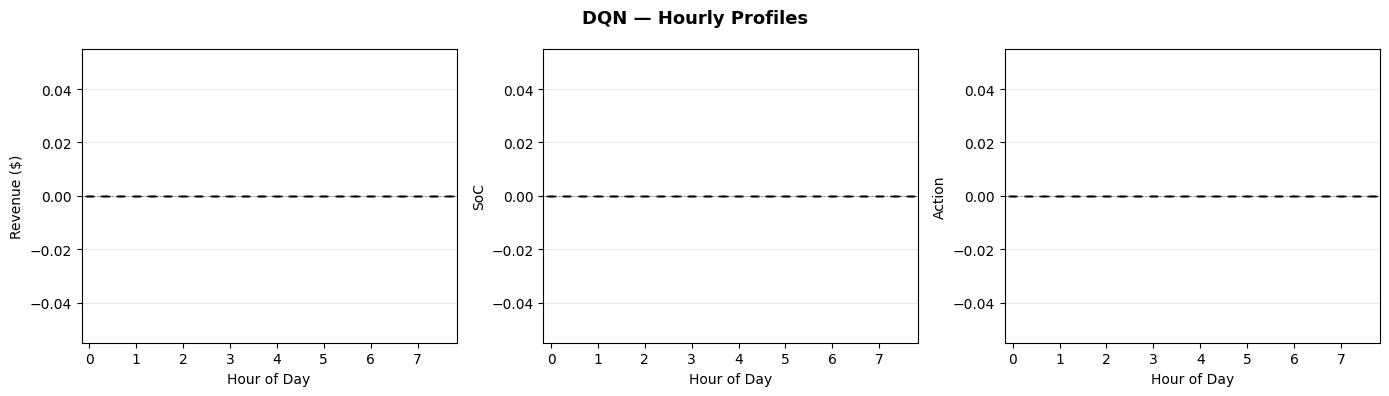

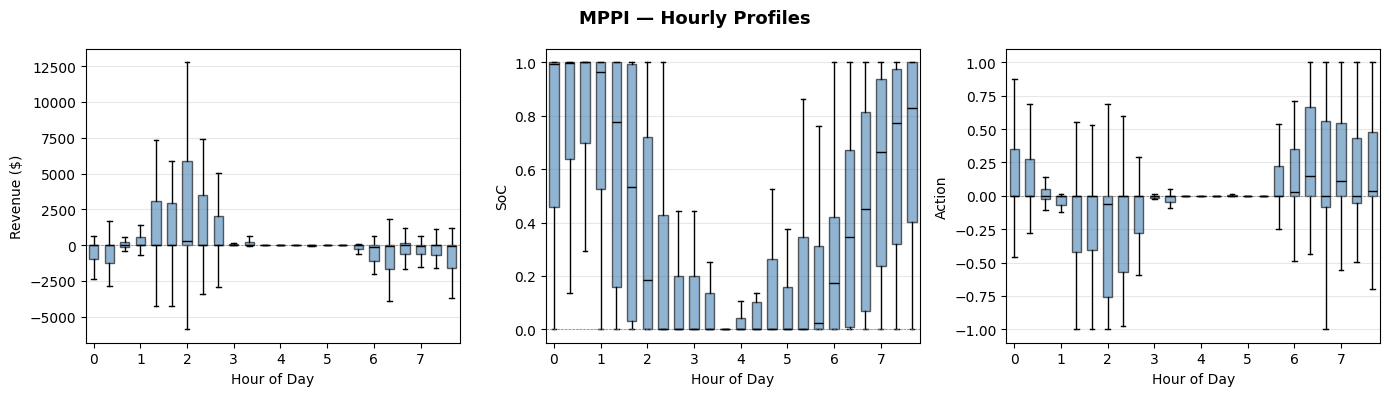

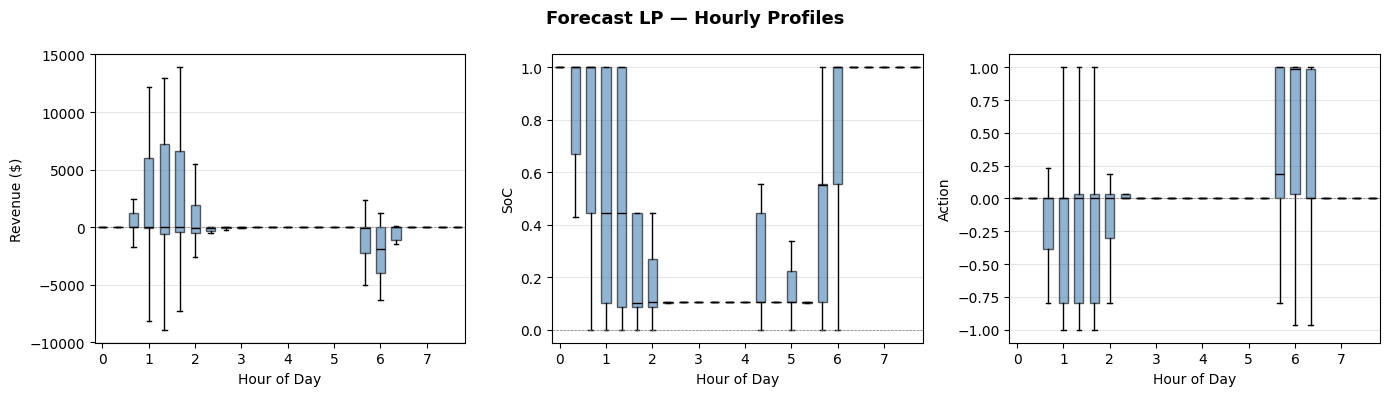

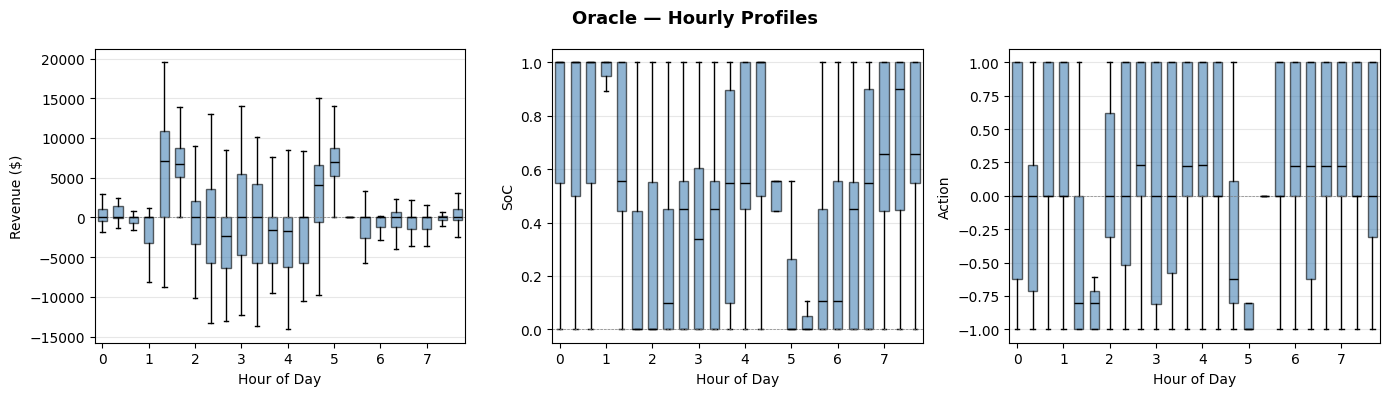

In [15]:
for e in all_evals:
    plot_hourly_profile(e)
    plt.show()

## 12. Detailed Time Series

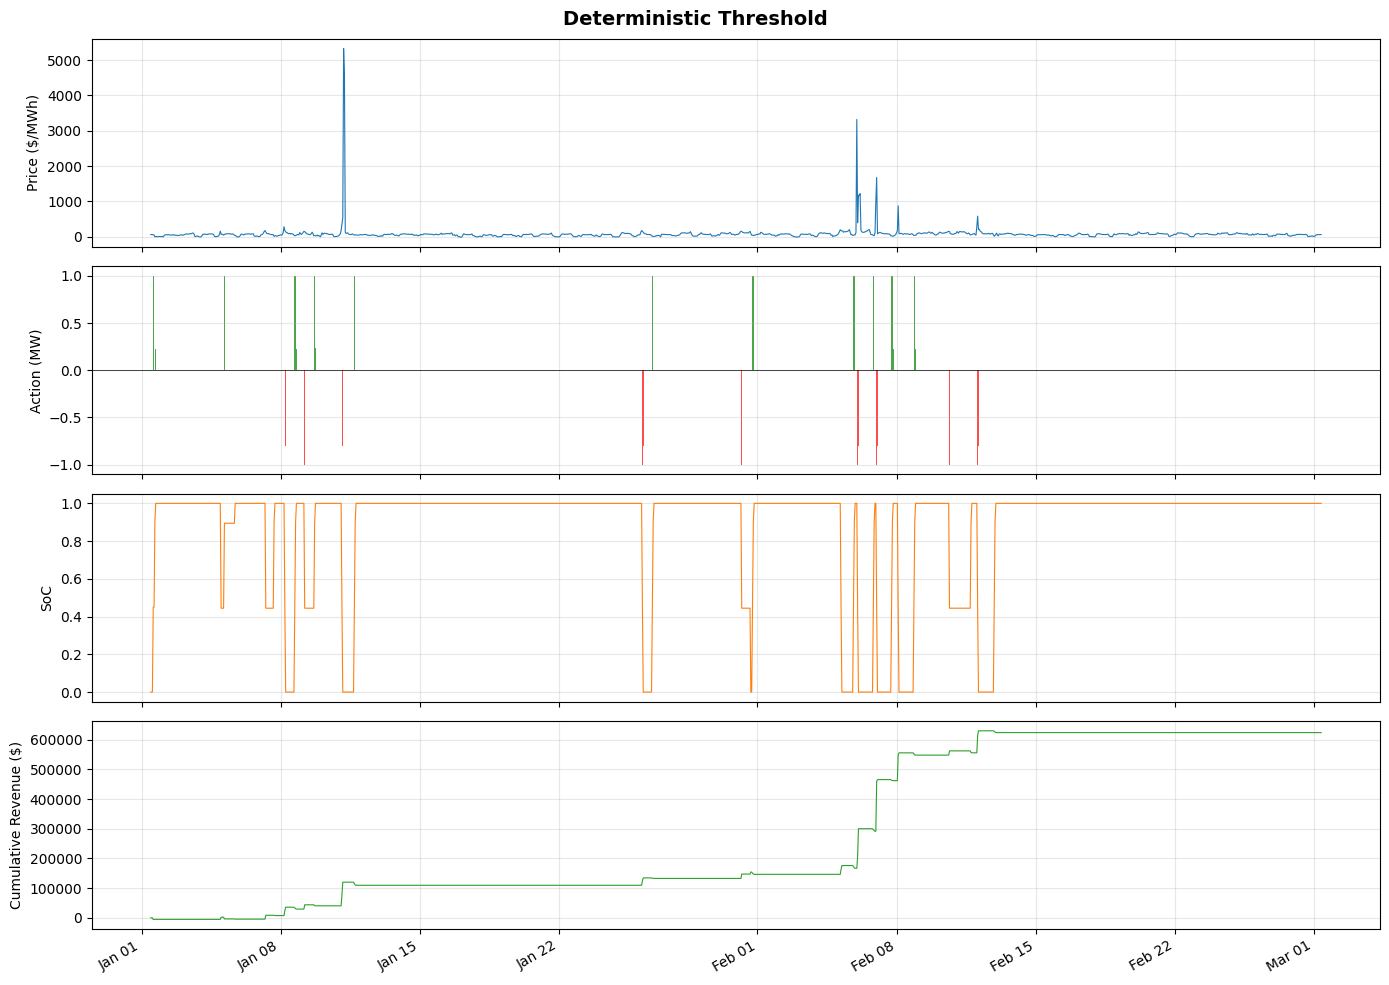

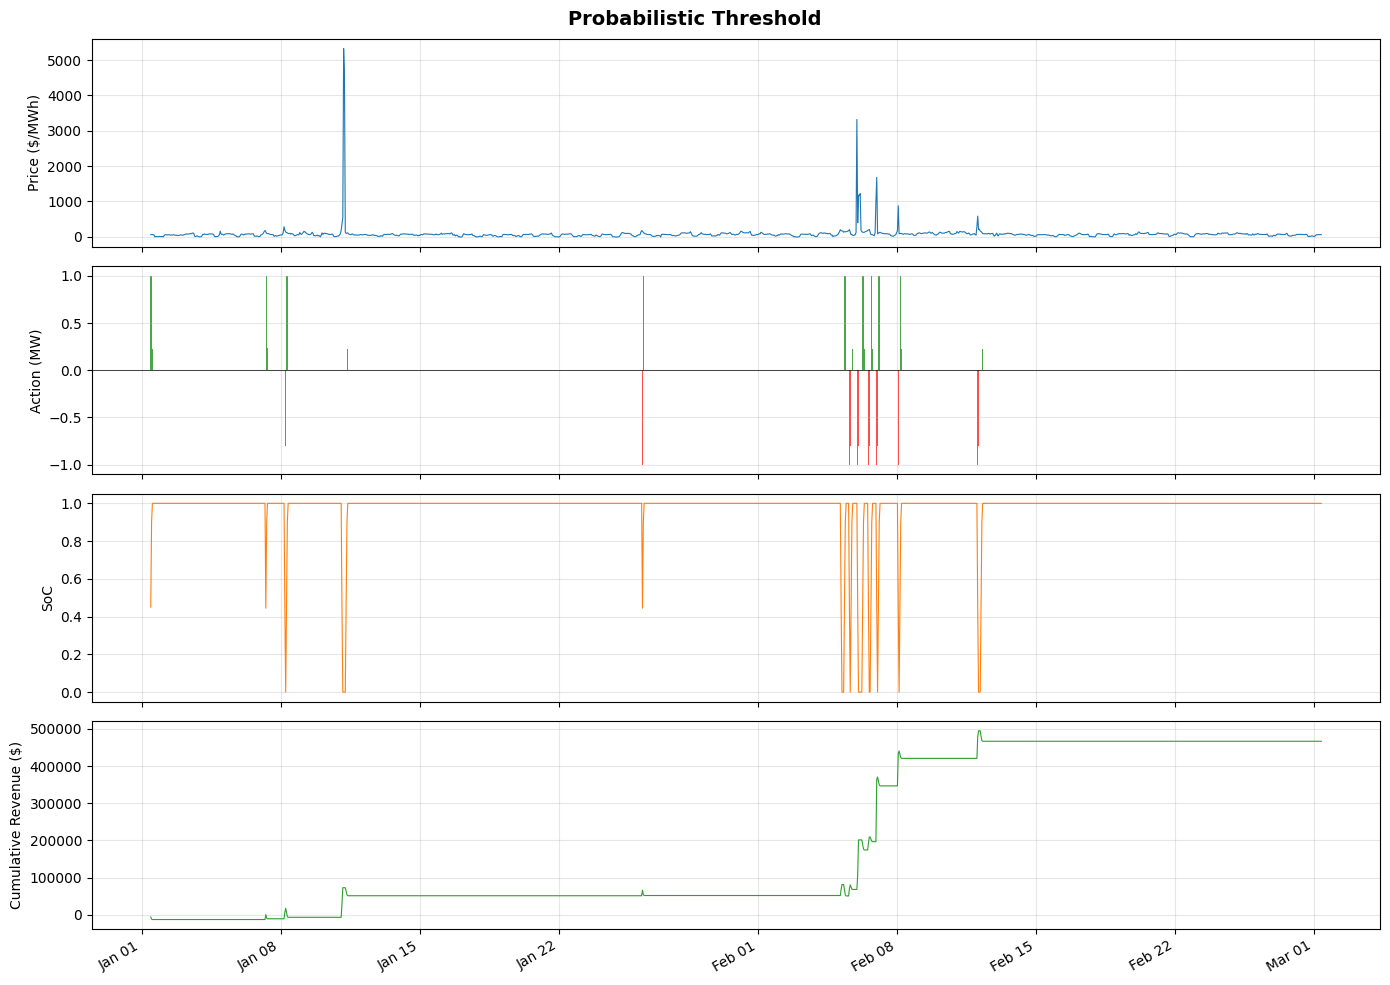

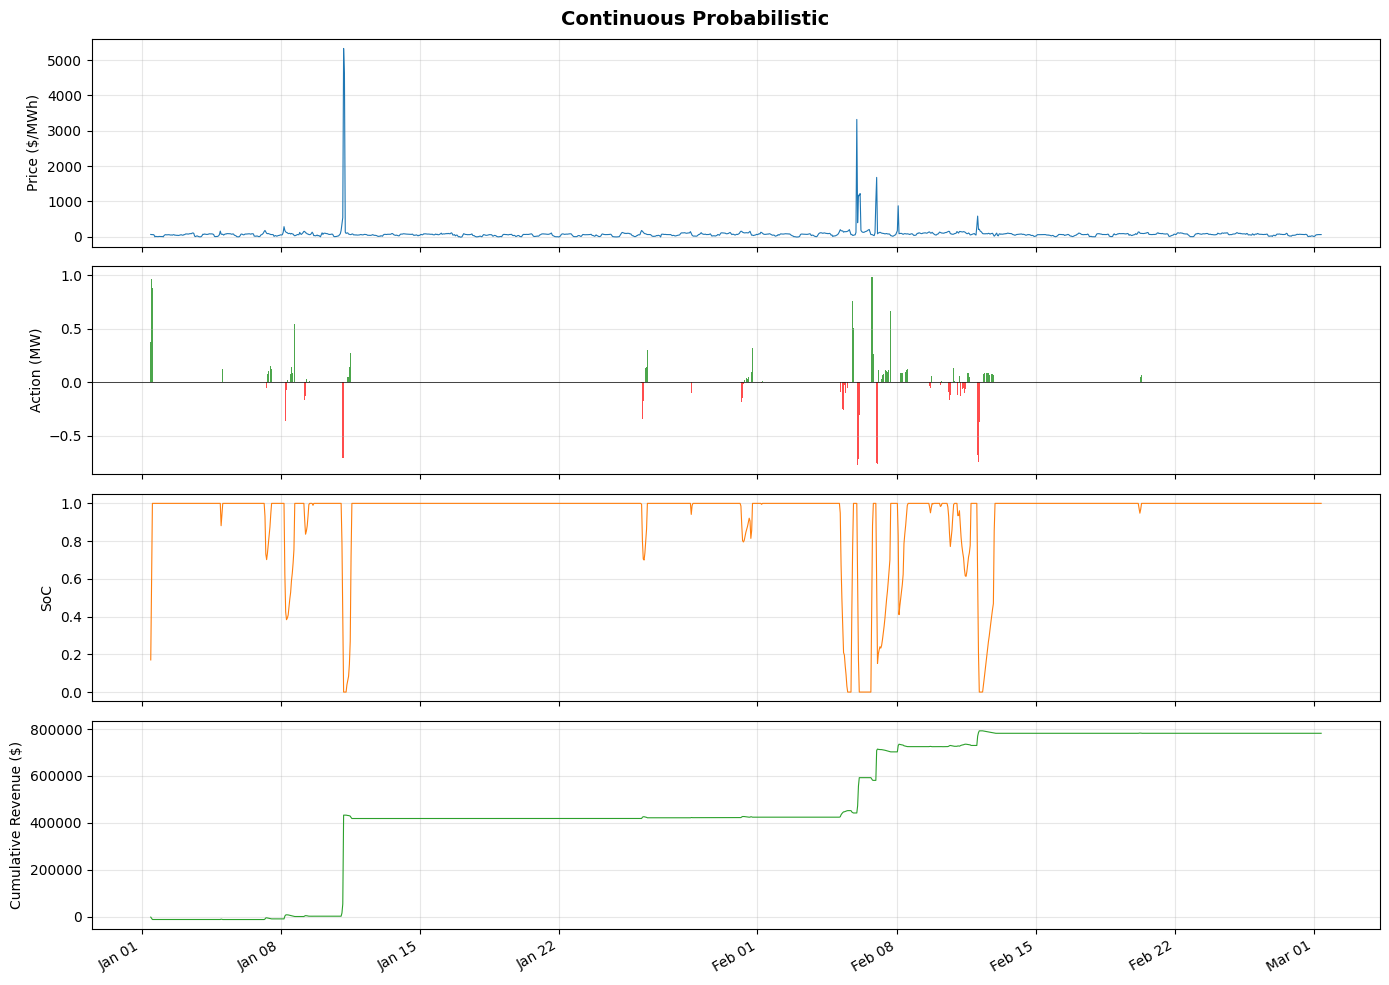

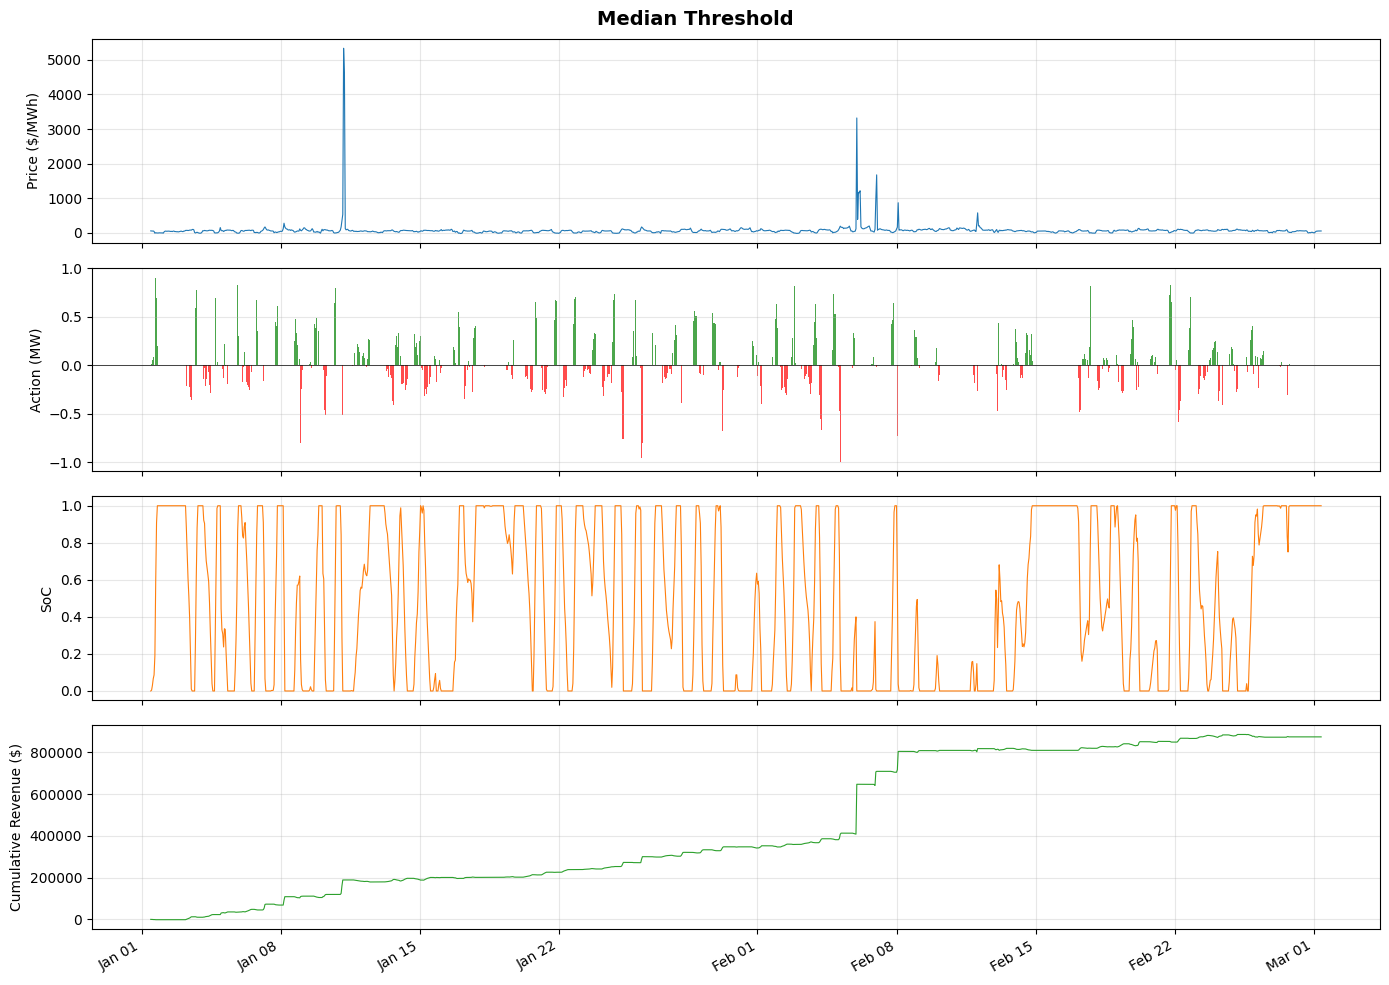

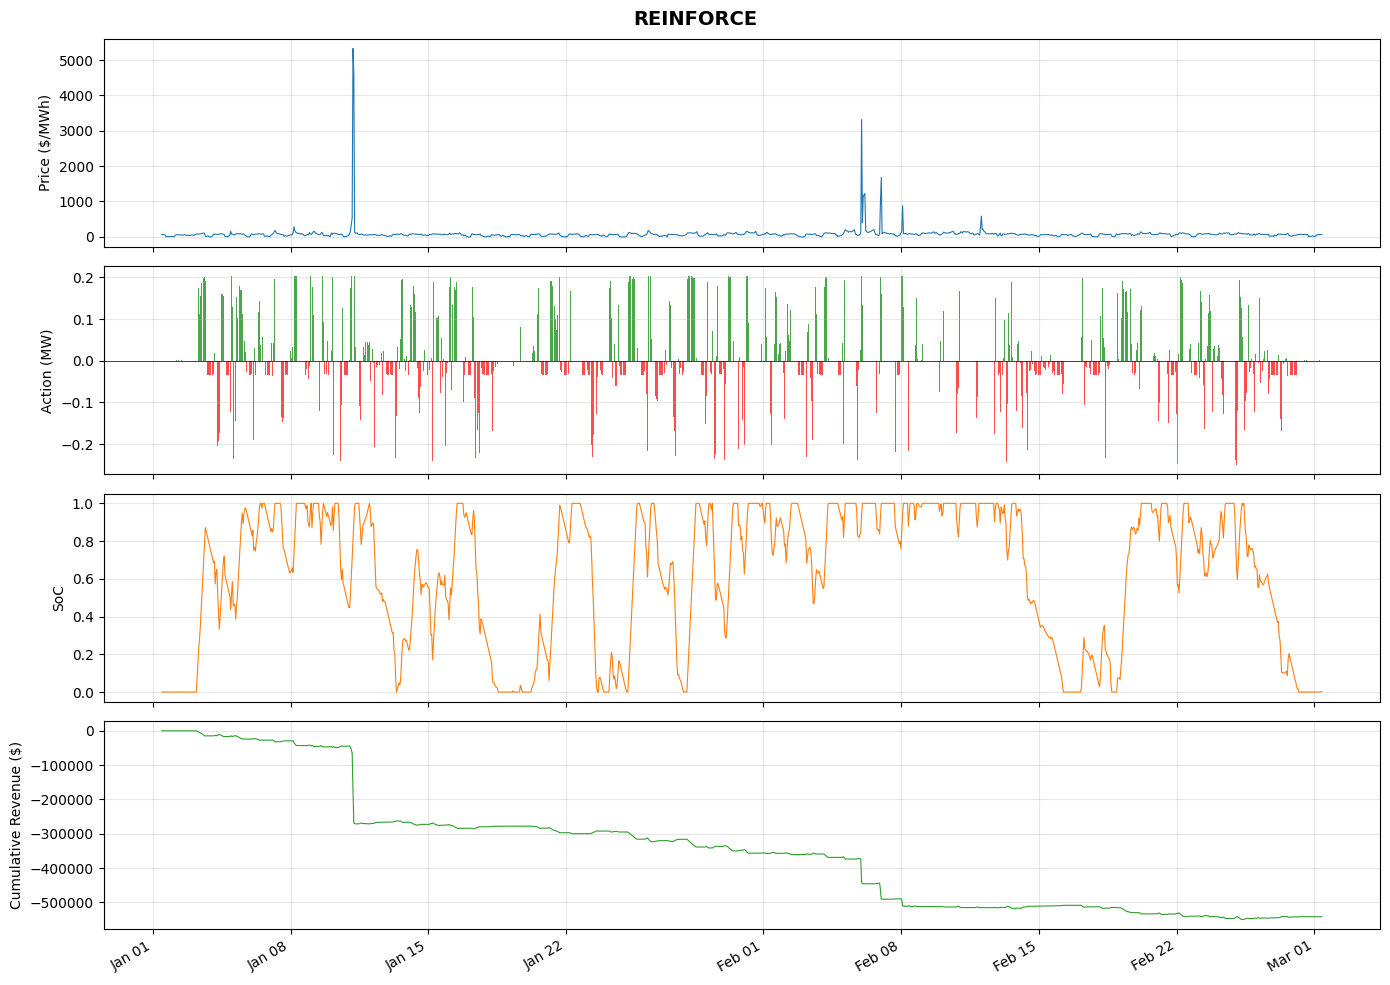

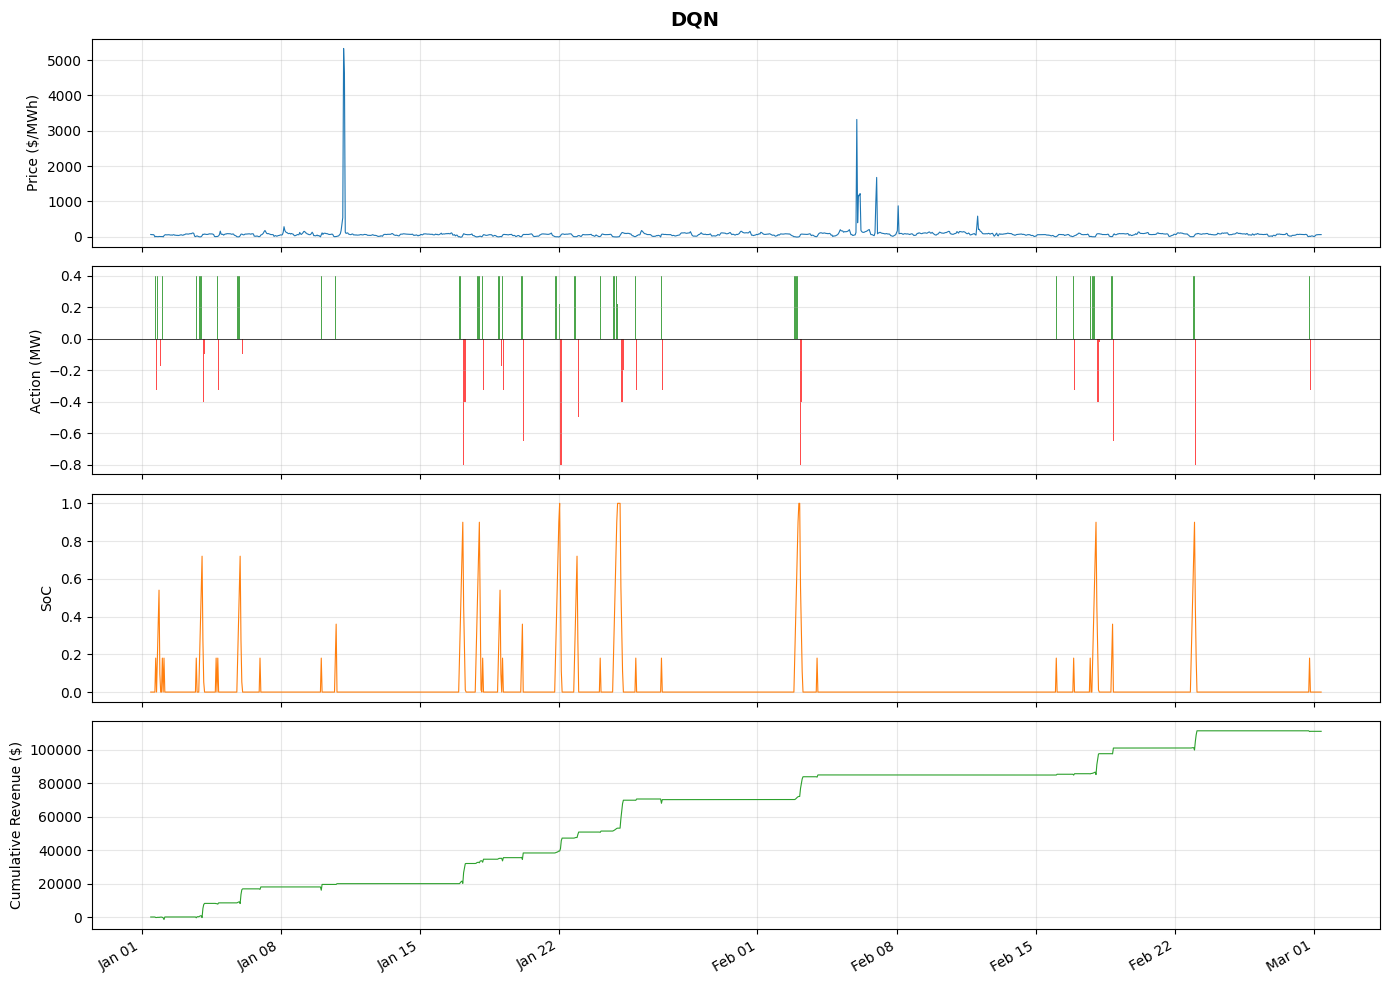

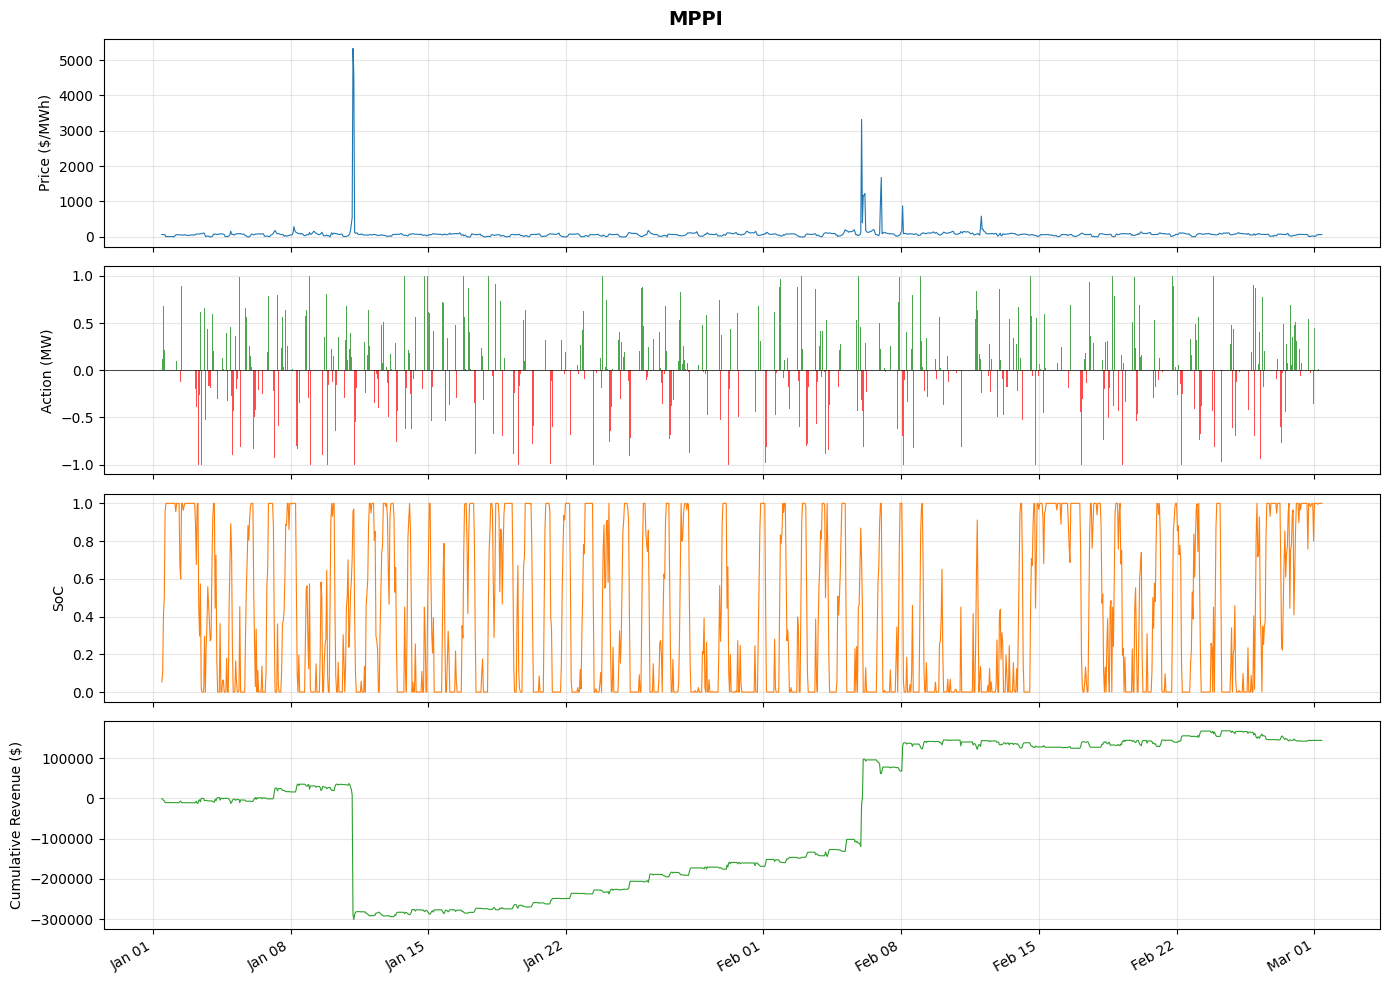

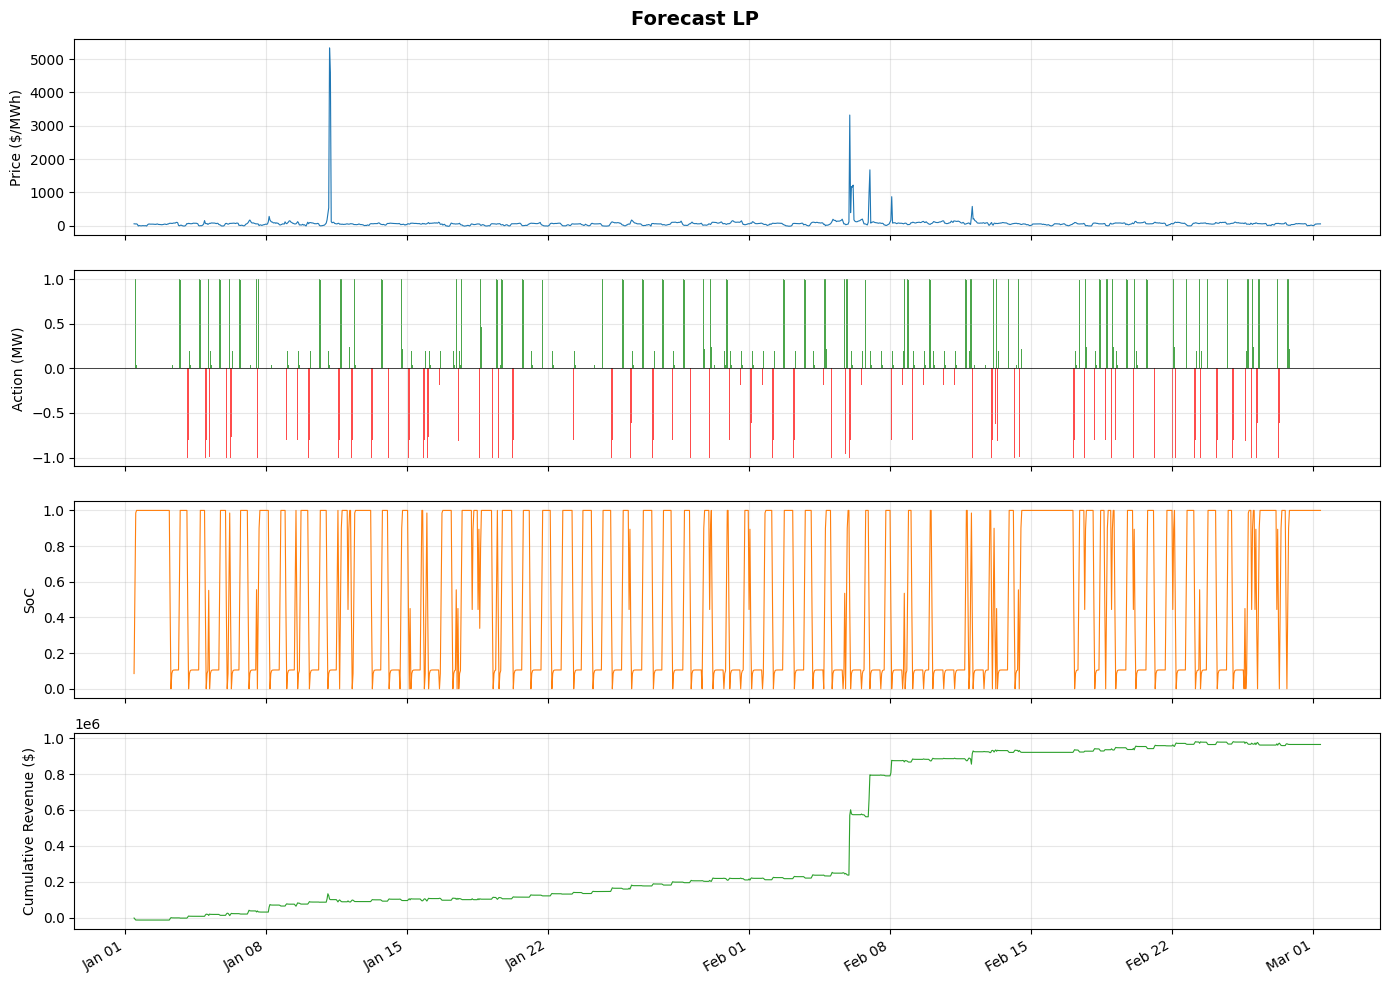

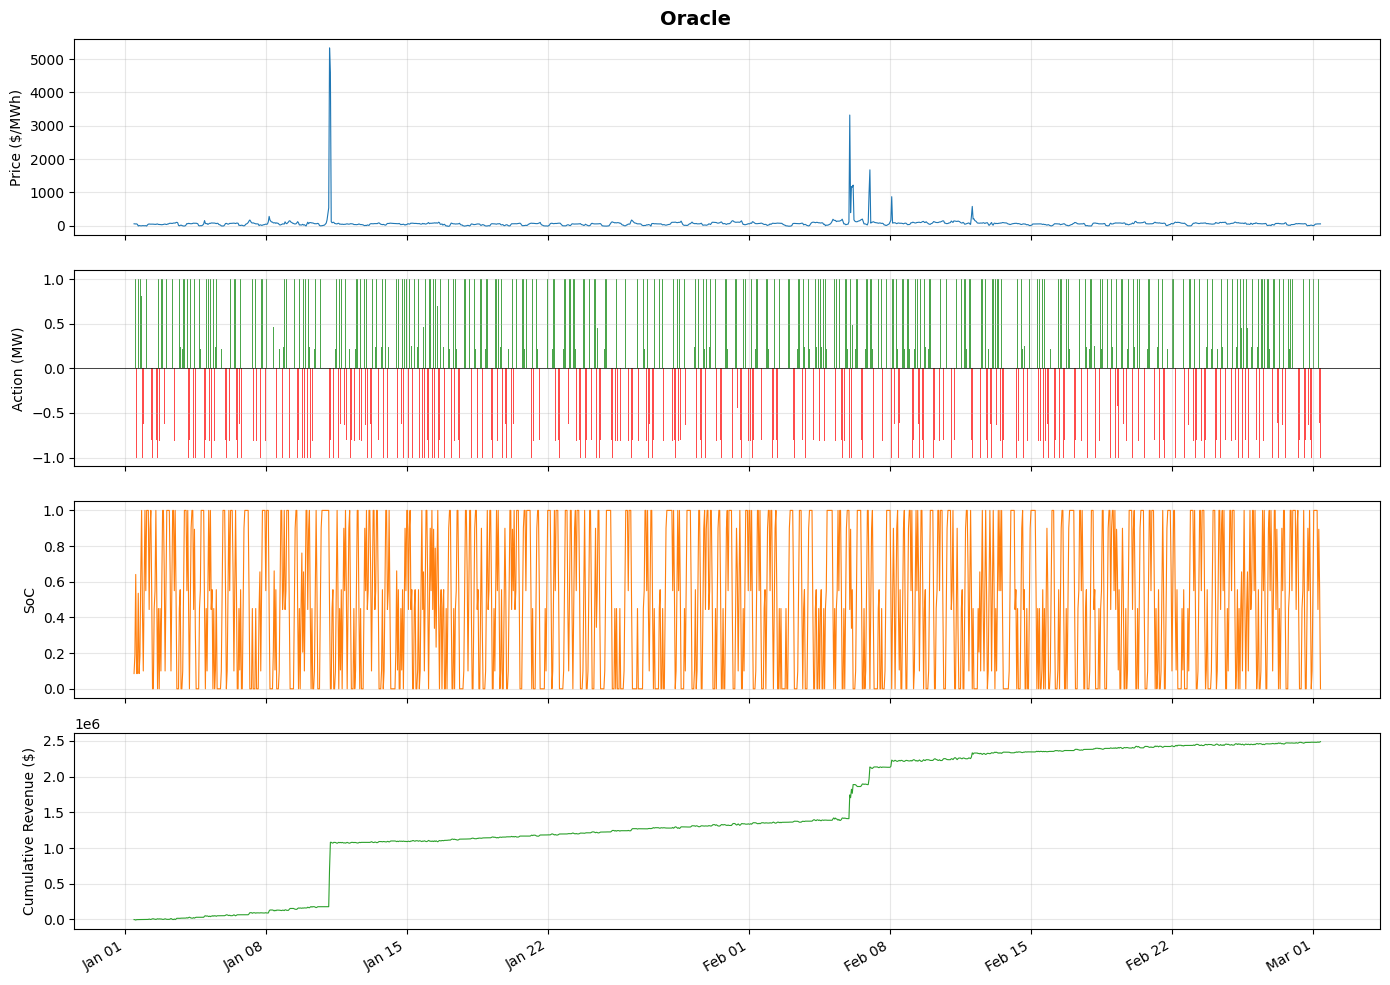

In [16]:
for e in all_evals:
    plot_eval(e)
    plt.show()

## 13. Policy Comparison

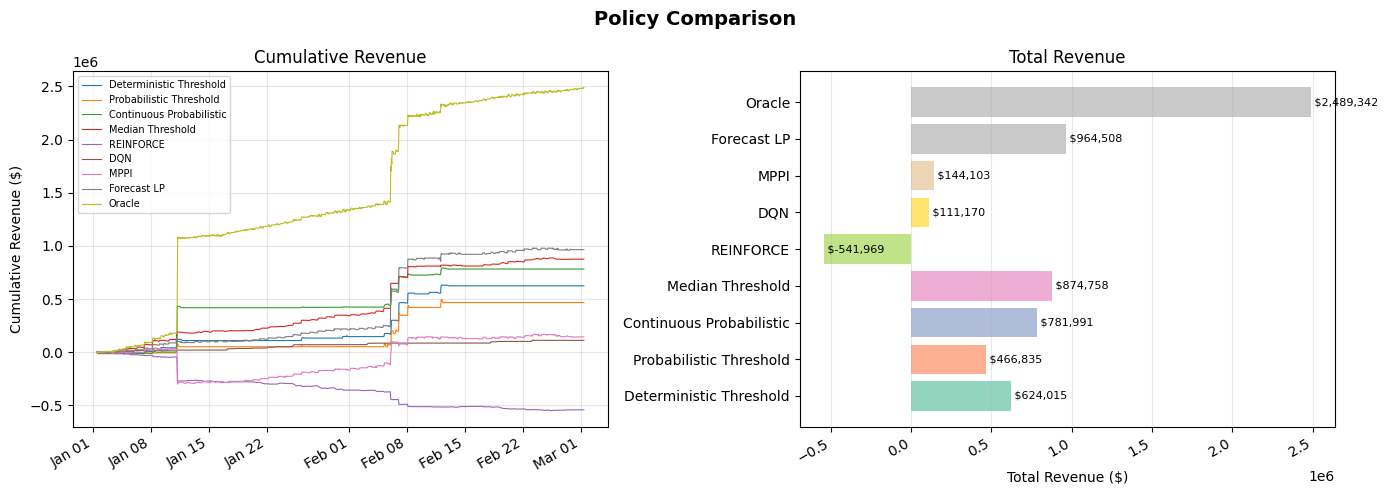

In [17]:
compare_policies(all_evals)
plt.show()